In [46]:
"""

WGAN (Wasserstein GAN)
"Wasserstein GAN" (Arjovsky, Chintala & Bottou, 2017)

"""

'\n\nWGAN (Wasserstein GAN)\n"Wasserstein GAN" (Arjovsky, Chintala & Bottou, 2017)\n\n'

In [47]:
import os

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision

from tqdm import tqdm
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [48]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("spandan2/cats-faces-64x64-for-generative-models")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'cats-faces-64x64-for-generative-models' dataset.
Path to dataset files: /kaggle/input/cats-faces-64x64-for-generative-models


In [49]:
# Optimize convolution algorithms for fixed input sizes to boost training speed
torch.backends.cudnn.benchmark = True

In [50]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

total_step = 5000
batch_size = 64
latent_size = 100

lr = 0.0002

In [51]:
PRINT_INTERVAL = 25
SAMPLE_INTERVAL = 200
CHECKPOINT_INTERVAL = 1000

sample_dir = "./samples"
checkpoint_dir = "./checkpoints"
os.makedirs(sample_dir, exist_ok=True)
os.makedirs(checkpoint_dir, exist_ok=True)

image shape: torch.Size([64, 3, 32, 32])
dataset size: 15747


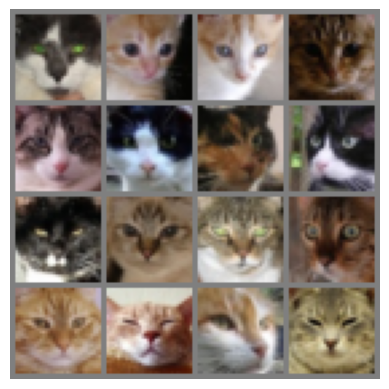

In [52]:
class ImageDataLoader:
    def __init__(self, dataloader):
        self.dataloader = dataloader
        self.iterator = iter(dataloader)

    def __iter__(self):
        return self

    def __next__(self):
        try:
            return next(self.iterator)[0]
        except StopIteration:
            self.iterator = iter(self.dataloader)
            return next(self.iterator)[0]

transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

dataset = datasets.ImageFolder(root=path, transform=transform)
data_loader = DataLoader(
    dataset=dataset,
    batch_size=batch_size,
    shuffle=True,
    drop_last=True
)
train_loader = ImageDataLoader(data_loader)

# Test
images = next(iter(train_loader))
print(f"image shape: {images.shape}")
print(f"dataset size: {len(dataset) // 2}")

images = torchvision.utils.make_grid(images[:16], nrow=4)
images = (images + 1) / 2 # [-1, 1] -> [0, 1]
plt.imshow(images.permute(1, 2, 0))
plt.axis("off")
plt.show()

In [53]:
#################### Generator ####################

class Generator(nn.Module):
    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(latent_size, 256 * 4 * 4),
            nn.Unflatten(1, (256, 4, 4)),

            UpBlock(256, 128), # (B, 256, 4, 4)  -> (B, 128, 8, 8)
            UpBlock(128, 64),  # (B, 128, 8, 8)  -> (B, 64, 16, 16)
            UpBlock(64, 32),   # (B, 64, 16, 16) -> (B, 32, 32, 32)

            nn.Conv2d(32, 3, 3, 1, 1), # (B, 3, 32, 32)
            nn.Tanh()
        )

        self.network.apply(init_weights)

    def forward(self, z):
        return self.network(z)

#################### UpBlock ####################

class UpBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.up = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear'),
            nn.Conv2d(in_channels, out_channels, 3, 1, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.LeakyReLU(0.2)
        )

    def forward(self, x):
        return self.up(x)

In [54]:
#################### Discriminator ####################

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            DownBlock(3, 64), # 32 -> 16
            DownBlock(64, 128),                # 16 -> 8
            DownBlock(128, 256),               # 8 -> 4

            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 1),
        )

        self.network.apply(init_weights)

    def forward(self, image):
        return self.network(image)

#################### DownBlock ####################

class DownBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.down = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, 2, 1),
            # nn.BatchNorm2d(out_channels) if use_norm else nn.Identity(),
            nn.LeakyReLU(0.2)
        )

    def forward(self, x):
        return self.down(x)

In [55]:
def init_weights(m):
    if isinstance(m, torch.nn.Conv2d) or isinstance(m, torch.nn.ConvTranspose2d):
        torch.nn.init.normal_(m.weight, 0.0, 0.02)
    elif isinstance(m, torch.nn.BatchNorm2d):
        torch.nn.init.normal_(m.weight, 1.0, 0.02)
        torch.nn.init.zeros_(m.bias)

In [56]:
def visualize_sample(fixed_z, step):
    generator.eval()
    with torch.no_grad():
        fake_images = generator(fixed_z).cpu()
        fake_images = (fake_images + 1) / 2  # [-1, 1] -> [0, 1]

        grid = torchvision.utils.make_grid(fake_images, nrow=8)
        plt.figure(figsize=(16, 4))
        plt.imshow(grid.permute(1, 2, 0))
        plt.axis("off")
        plt.tight_layout()
        plt.show()

        torchvision.utils.save_image(
            fake_images,
            f"{sample_dir}/step_{step:03d}.png",
            nrow=8
        )
    generator.train()

def save_checkpoint(step):
    torch.save({
        "step": step,
        "generator": generator.state_dict(),
        "discriminator": discriminator.state_dict(),
        "optimizer_G": optimizer_G.state_dict(),
        "optimizer_D": optimizer_D.state_dict(),
    }, f"{checkpoint_dir}/gan_step_{step:03d}.pth")

def load_checkpoint(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location=device)

    generator.load_state_dict(checkpoint["generator"])
    discriminator.load_state_dict(checkpoint["discriminator"])
    optimizer_G.load_state_dict(checkpoint["optimizer_G"])
    optimizer_D.load_state_dict(checkpoint["optimizer_D"])
    start_step = checkpoint["step"]
    print(f"Loaded checkpoint: {checkpoint_path} (step {start_step})")
    return start_step

In [57]:
generator = Generator().to(device)
discriminator = Discriminator().to(device)

optimizer_G = optim.RMSprop(generator.parameters(), lr=lr)
optimizer_D = optim.RMSprop(discriminator.parameters(), lr=lr)

In [58]:
# if pretrained
# path = "./checkpoints/gan_epoch_1000.pth"
# start_step = load_checkpoint(path)
start_step = 0

D_loss: 0.7376  G_loss: -8.5099  D(x): 6.685  D(G(z)): 8.510:   4%|▍         | 198/5000 [00:15<06:34, 12.18it/s]    

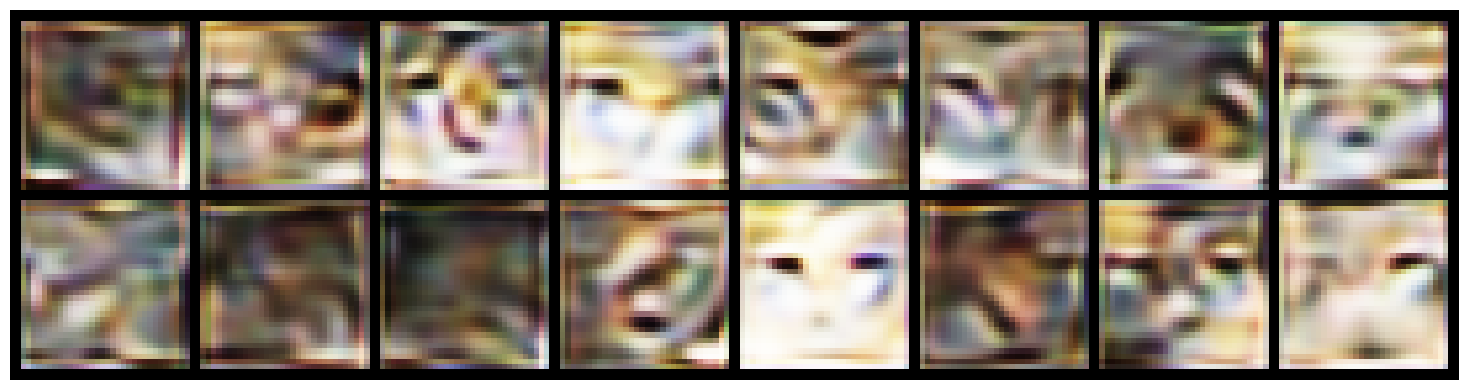

D_loss: -1.7955  G_loss: -11.6467  D(x): 10.845  D(G(z)): 11.647:   8%|▊         | 398/5000 [00:31<05:31, 13.88it/s]

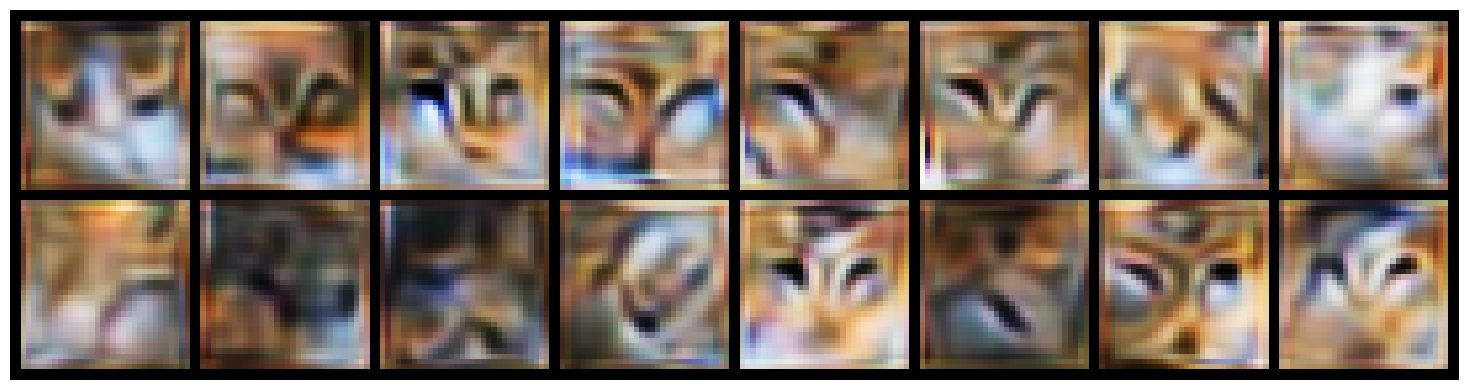

D_loss: 0.1988  G_loss: -13.6291  D(x): 18.662  D(G(z)): 13.629:  12%|█▏        | 598/5000 [00:46<05:20, 13.72it/s] 

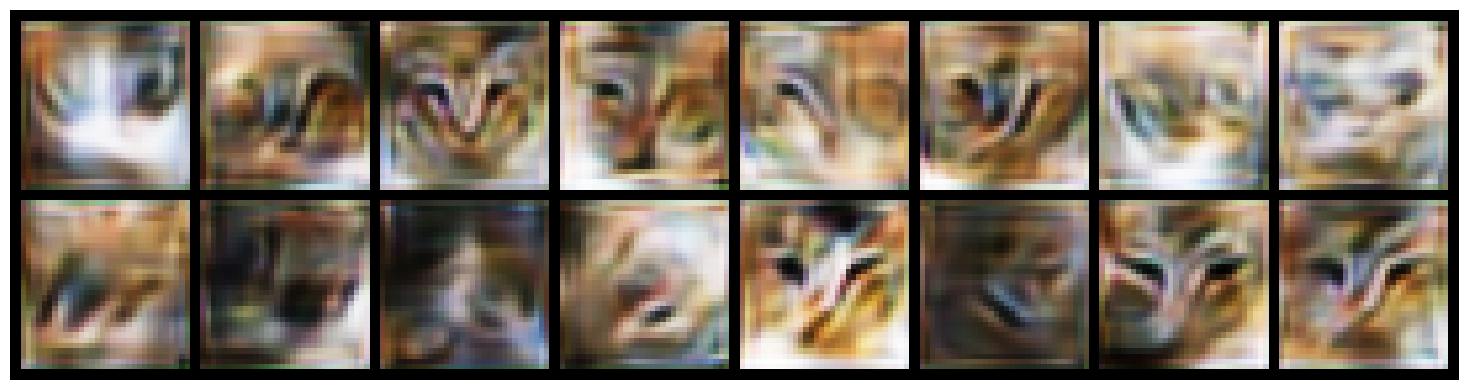

D_loss: -1.0414  G_loss: -13.6265  D(x): 13.878  D(G(z)): 13.626:  16%|█▌        | 798/5000 [01:02<05:42, 12.26it/s]

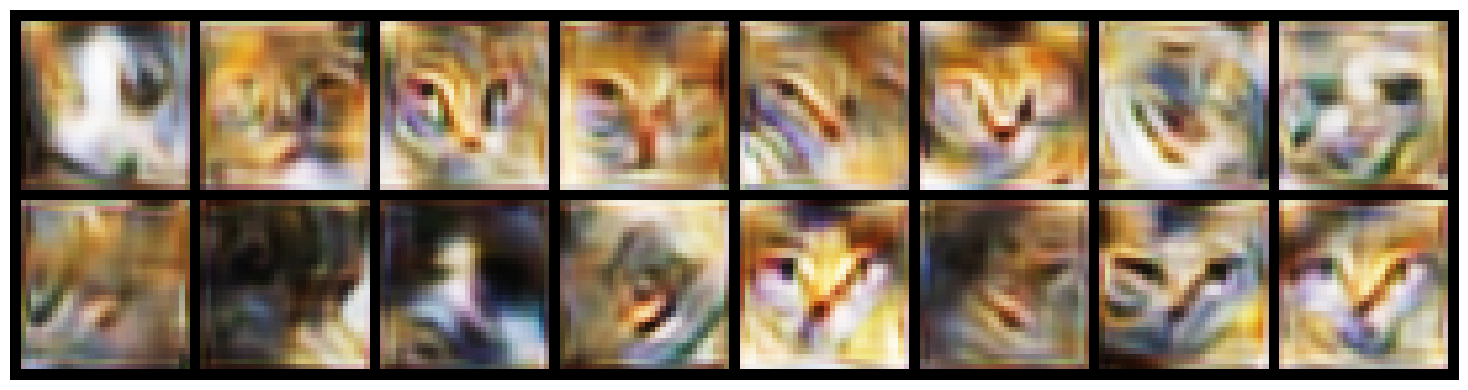

D_loss: -0.4597  G_loss: -13.7360  D(x): 13.887  D(G(z)): 13.736:  20%|█▉        | 998/5000 [01:18<04:48, 13.87it/s]

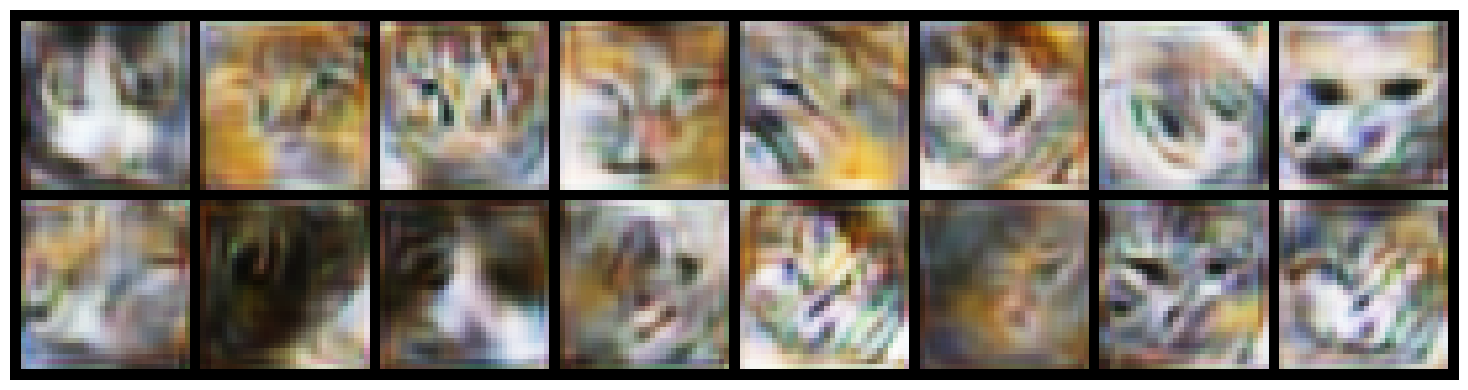

D_loss: -0.6391  G_loss: -15.2816  D(x): 17.077  D(G(z)): 15.282:  24%|██▍       | 1198/5000 [01:33<04:33, 13.92it/s]

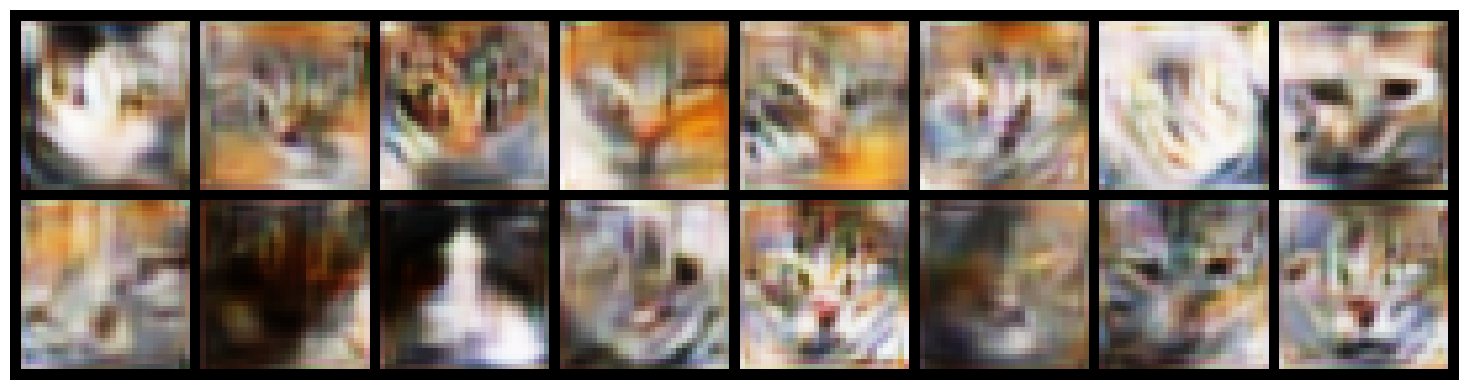

D_loss: -1.0256  G_loss: -13.3263  D(x): 15.438  D(G(z)): 13.326:  28%|██▊       | 1398/5000 [01:48<04:27, 13.49it/s]

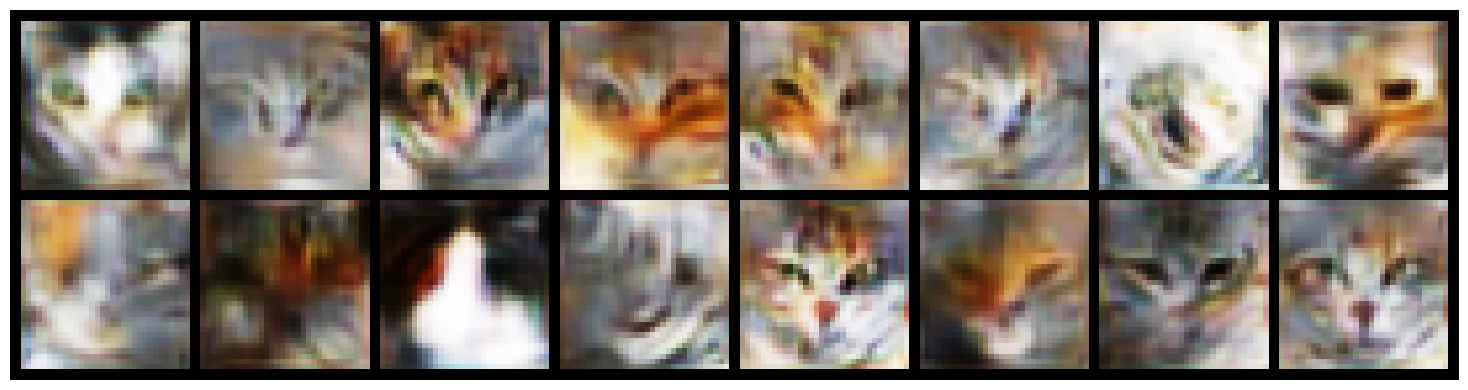

D_loss: -1.5118  G_loss: -7.6774  D(x): 10.510  D(G(z)): 7.677:  32%|███▏      | 1598/5000 [02:03<04:11, 13.54it/s]

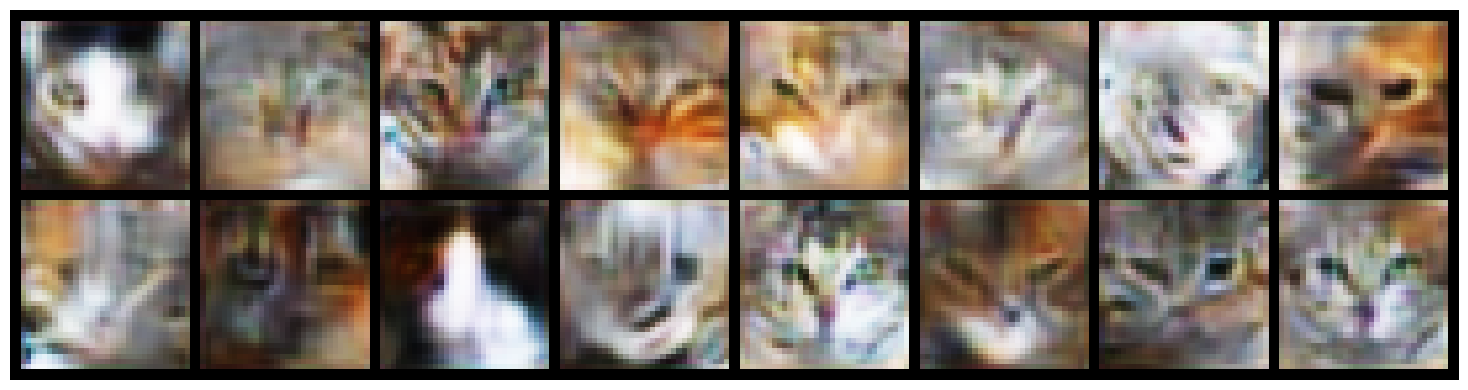

D_loss: -1.0338  G_loss: -9.3587  D(x): 10.191  D(G(z)): 9.359:  36%|███▌      | 1798/5000 [02:18<04:04, 13.11it/s]  

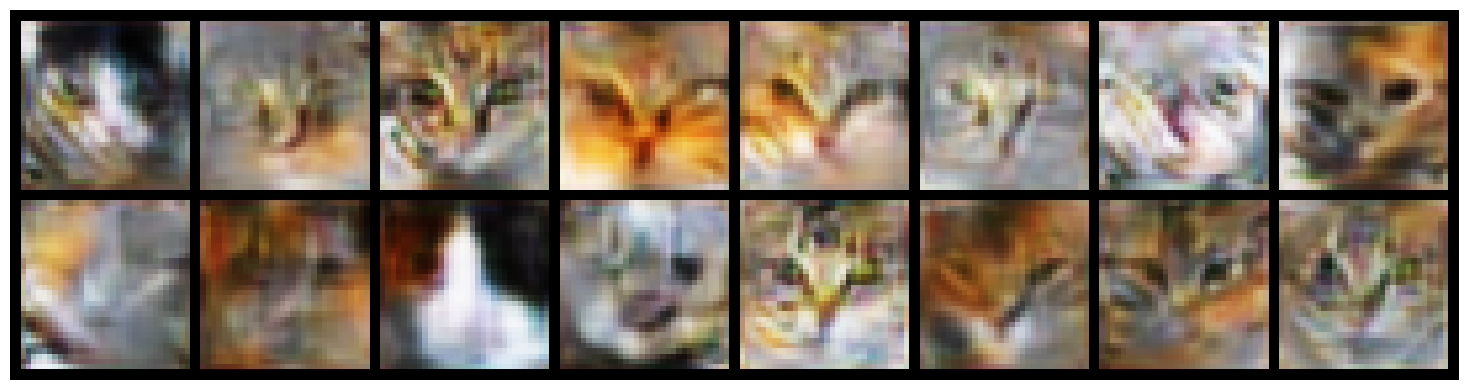

D_loss: -1.0417  G_loss: -5.5134  D(x): 7.759  D(G(z)): 5.513:  40%|███▉      | 1998/5000 [02:36<04:10, 11.97it/s]

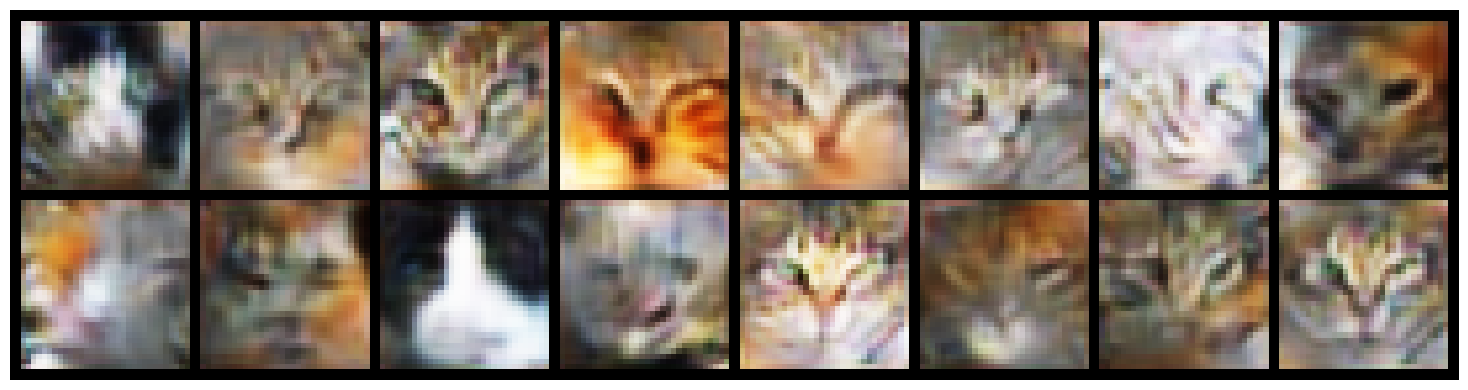

D_loss: -0.9084  G_loss: -8.8704  D(x): 8.323  D(G(z)): 8.870:  44%|████▍     | 2198/5000 [02:52<03:28, 13.45it/s] 

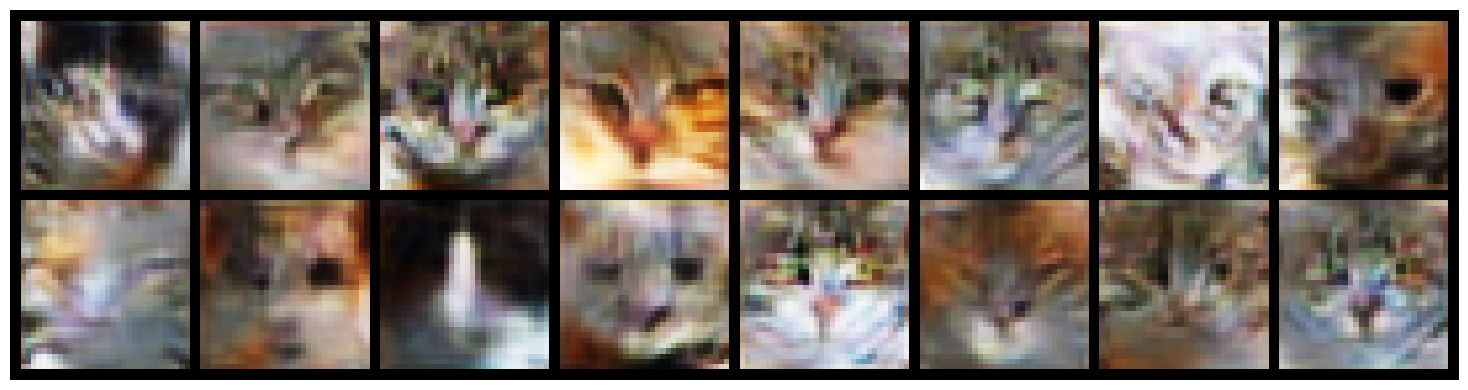

D_loss: -0.6423  G_loss: -2.2092  D(x): 3.622  D(G(z)): 2.209:  48%|████▊     | 2398/5000 [03:08<03:27, 12.51it/s]

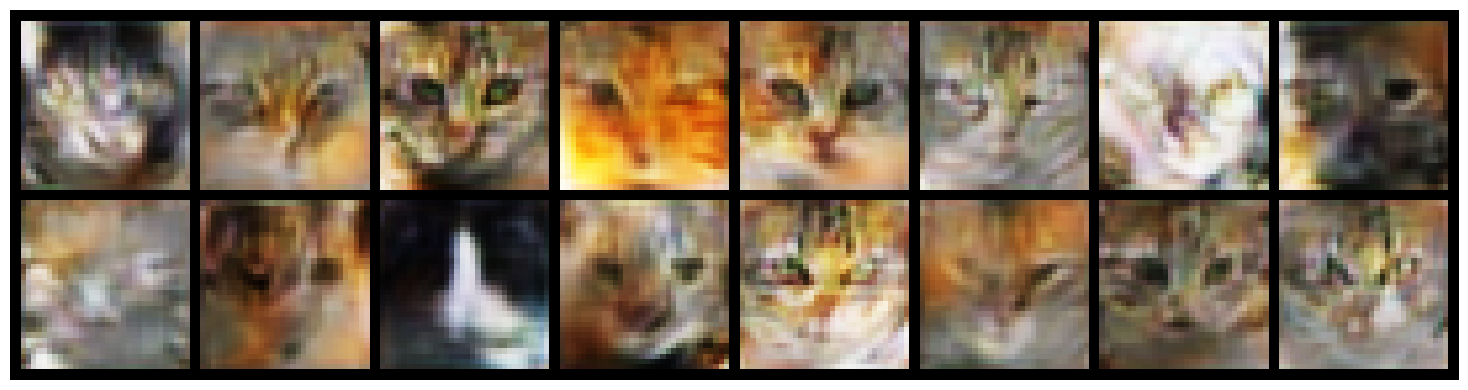

D_loss: -0.7519  G_loss: -5.3359  D(x): 6.004  D(G(z)): 5.336:  52%|█████▏    | 2598/5000 [03:23<02:56, 13.57it/s]

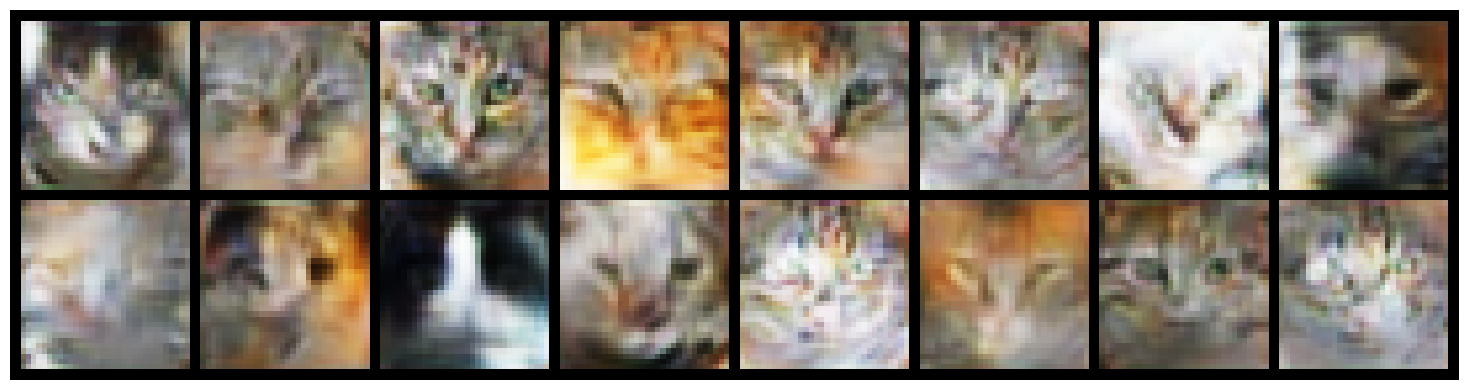

D_loss: -0.6145  G_loss: -8.1646  D(x): 9.111  D(G(z)): 8.165:  56%|█████▌    | 2798/5000 [03:38<02:38, 13.86it/s]

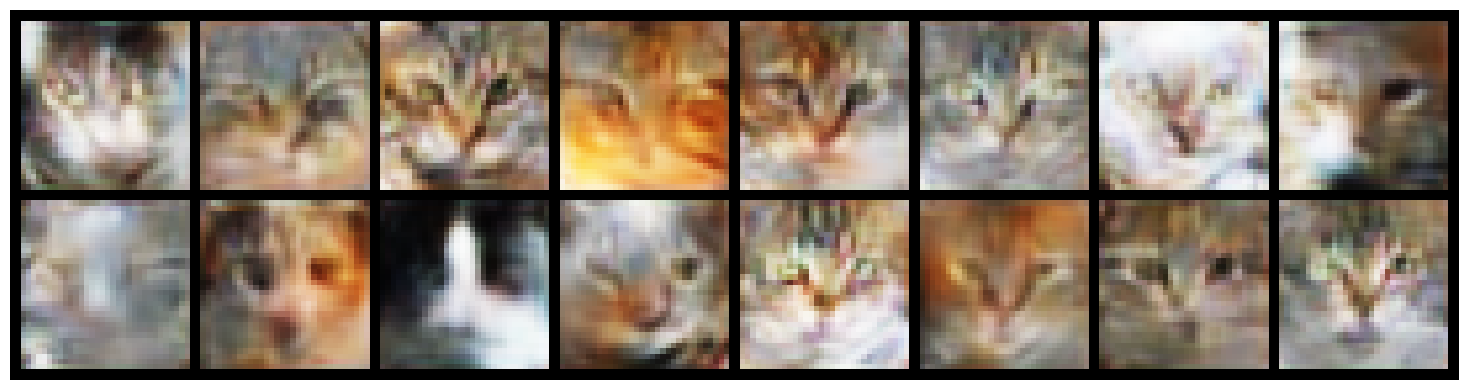

D_loss: 0.1227  G_loss: -9.1144  D(x): 9.923  D(G(z)): 9.114:  60%|█████▉    | 2998/5000 [03:53<02:28, 13.49it/s] 

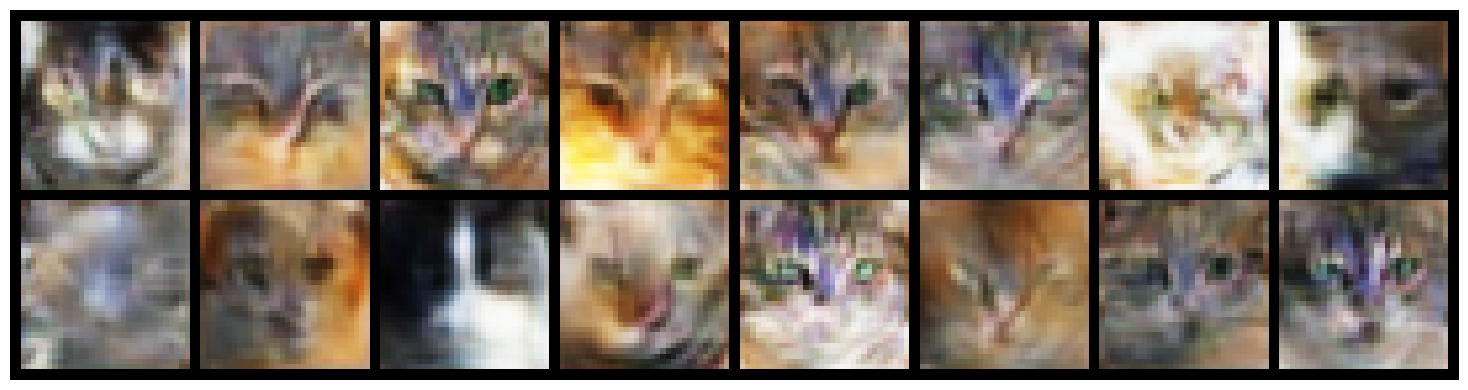

D_loss: -1.1790  G_loss: -4.8497  D(x): 6.976  D(G(z)): 4.850:  64%|██████▍   | 3198/5000 [04:09<02:44, 10.97it/s]

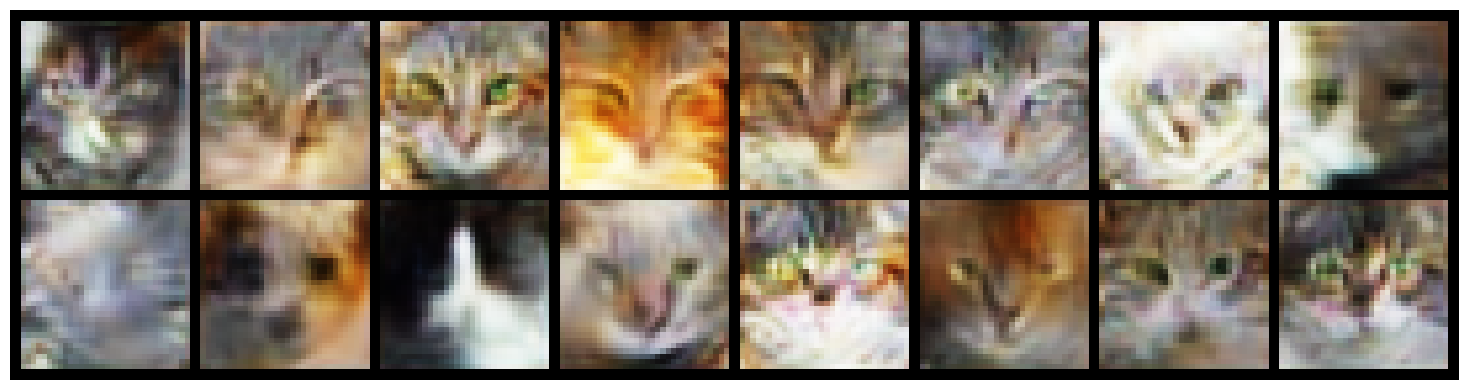

D_loss: -0.6417  G_loss: -4.3916  D(x): 4.863  D(G(z)): 4.392:  68%|██████▊   | 3398/5000 [04:24<02:03, 12.99it/s] 

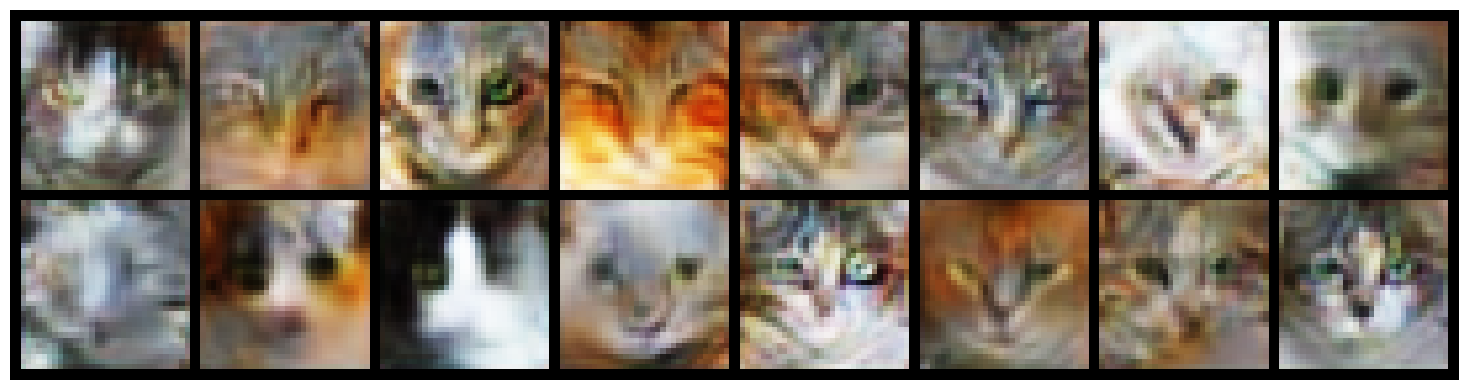

D_loss: -1.9141  G_loss: -8.9044  D(x): 10.343  D(G(z)): 8.904:  72%|███████▏  | 3598/5000 [04:40<01:44, 13.47it/s]

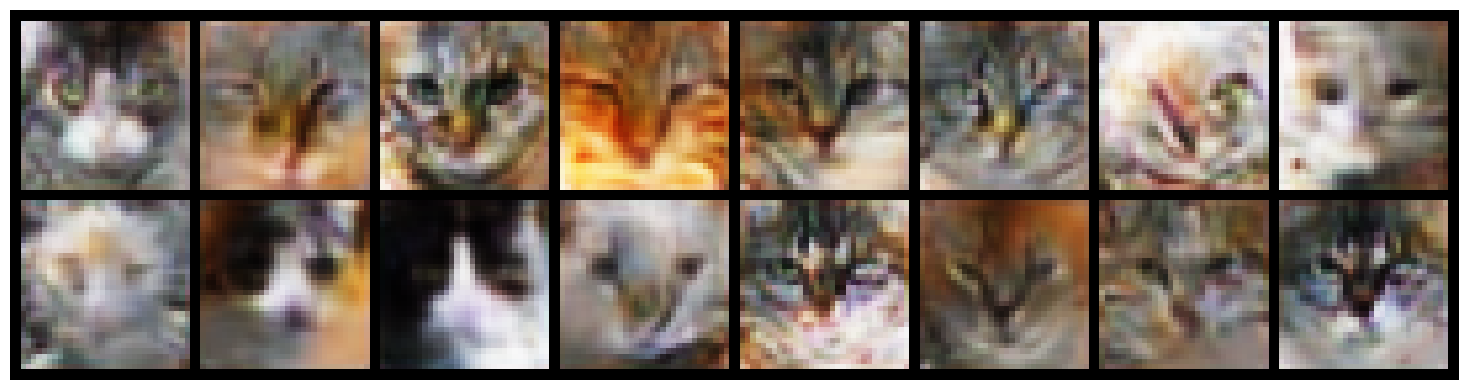

D_loss: -1.2181  G_loss: -8.3425  D(x): 9.485  D(G(z)): 8.342:  76%|███████▌  | 3798/5000 [04:55<01:27, 13.75it/s]

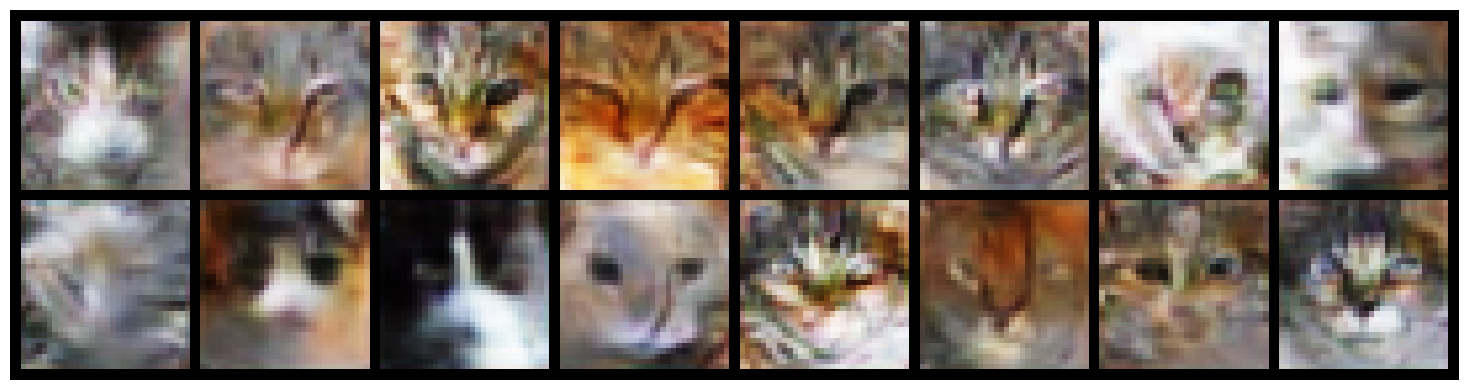

D_loss: -0.4836  G_loss: -7.2764  D(x): 7.090  D(G(z)): 7.276:  80%|███████▉  | 3998/5000 [05:11<01:32, 10.84it/s] 

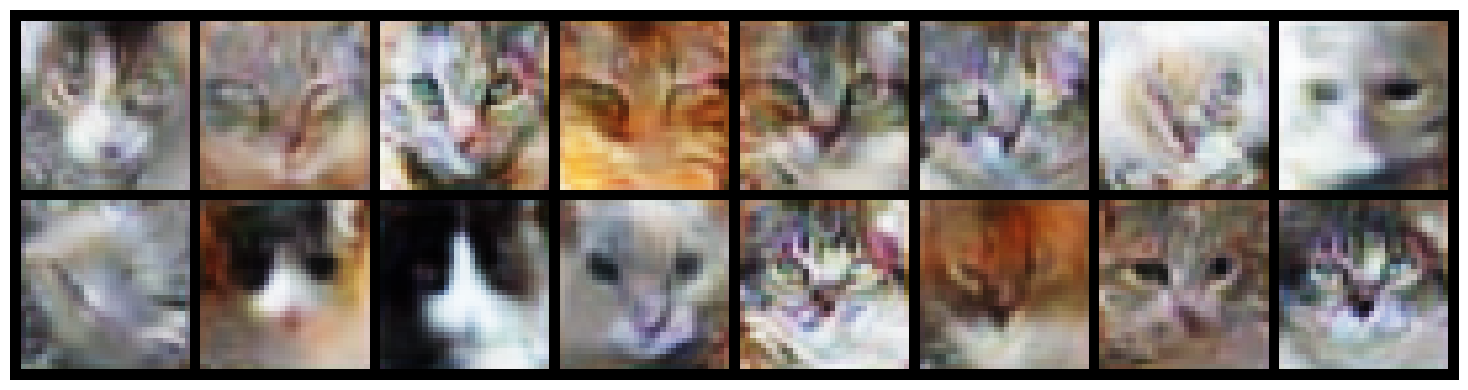

D_loss: -0.7138  G_loss: -4.9420  D(x): 6.266  D(G(z)): 4.942:  84%|████████▍ | 4198/5000 [05:27<01:00, 13.18it/s]

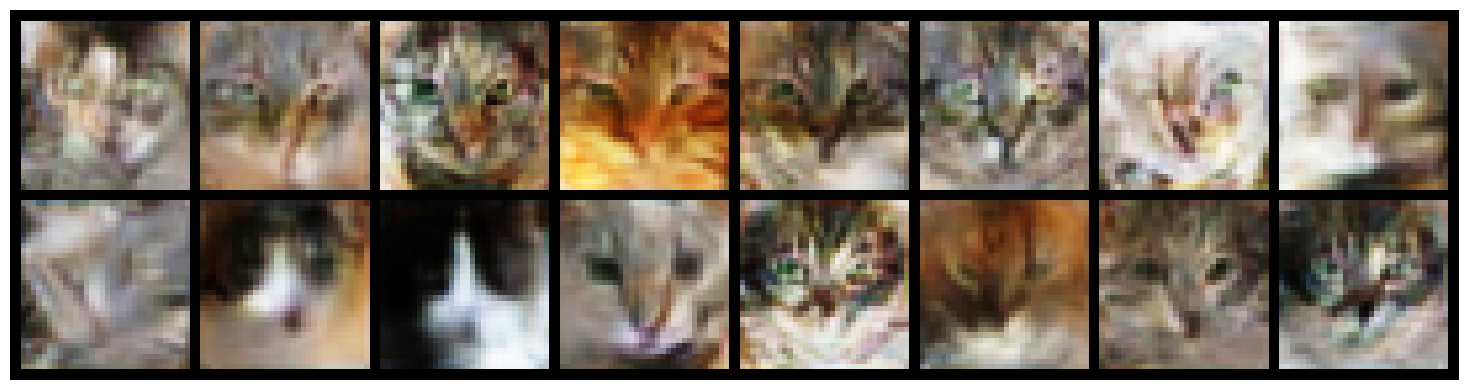

D_loss: -0.7614  G_loss: -8.3205  D(x): 8.147  D(G(z)): 8.320:  88%|████████▊ | 4398/5000 [05:42<00:44, 13.67it/s]

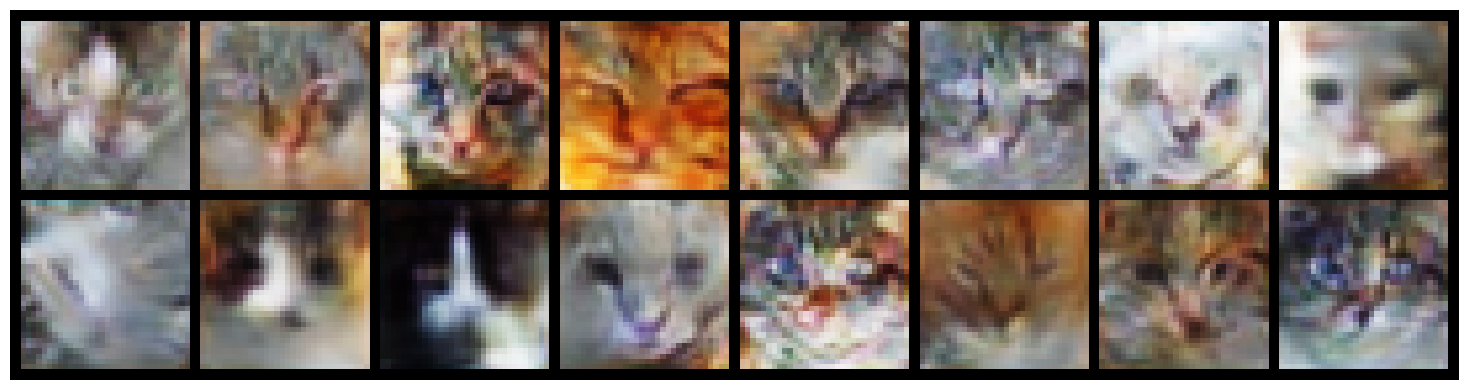

D_loss: 0.2242  G_loss: -7.9432  D(x): 9.111  D(G(z)): 7.943:  92%|█████████▏| 4598/5000 [05:58<00:29, 13.63it/s]

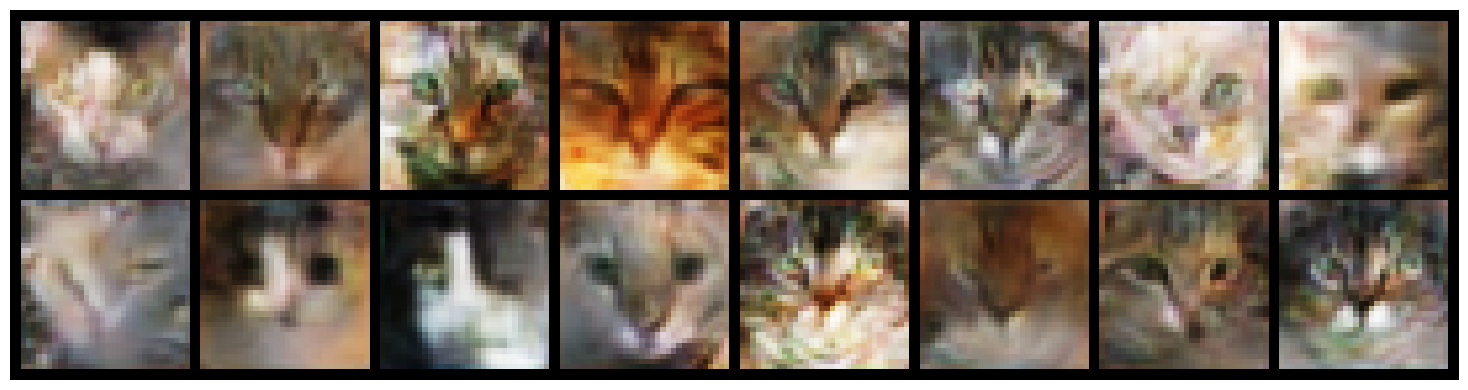

D_loss: -0.4531  G_loss: -4.2282  D(x): 4.934  D(G(z)): 4.228:  96%|█████████▌| 4798/5000 [06:14<00:16, 12.33it/s]

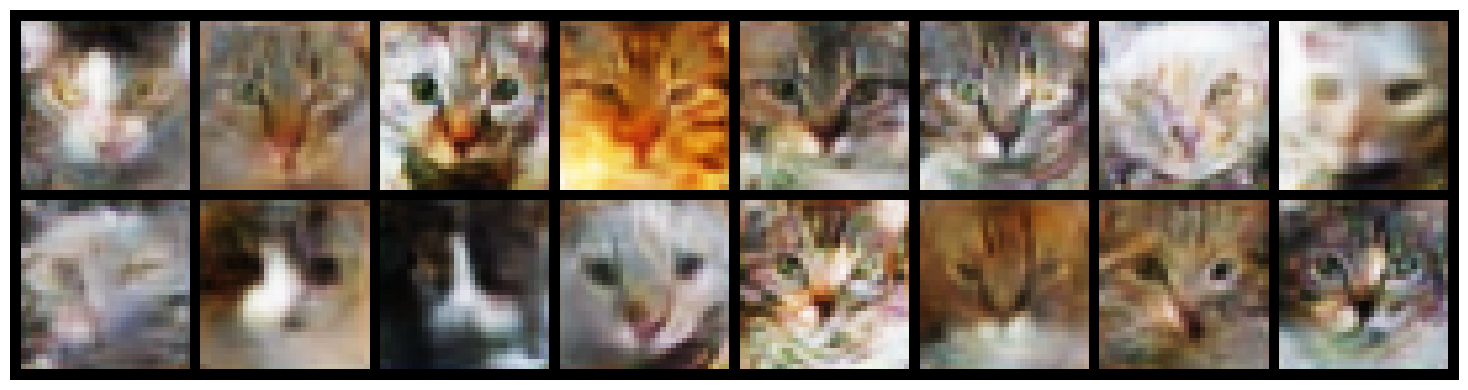

D_loss: -0.9349  G_loss: -8.0819  D(x): 9.061  D(G(z)): 8.082: 100%|█████████▉| 4998/5000 [06:30<00:00, 12.85it/s]

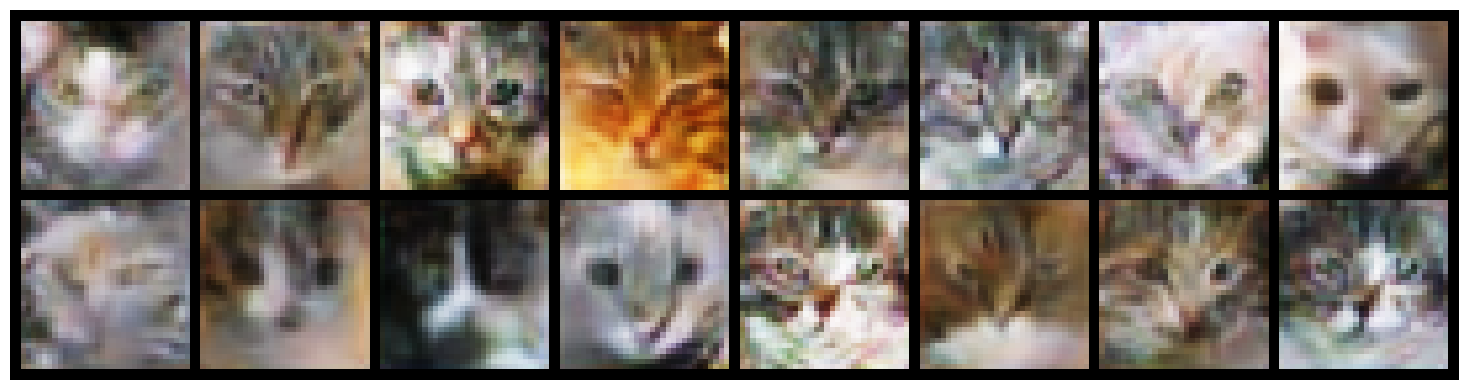

D_loss: -0.9349  G_loss: -8.0819  D(x): 9.061  D(G(z)): 8.082: 100%|██████████| 5000/5000 [06:30<00:00, 12.80it/s]


In [59]:
########## Train ##########

fixed_z_generator = torch.Generator(device=device).manual_seed(42)
fixed_z = torch.randn(16, latent_size, generator=fixed_z_generator, device=device) # for eval
# real_targets = torch.ones(batch_size, 1, device=device)  # (b, 1)
# fake_targets = torch.zeros(batch_size, 1, device=device) # (b, 1)

pbar = tqdm(range(start_step, total_step), desc="WGAN")

for step in pbar:
    real_images = next(train_loader).to(device)

    ########## D Train ##########
    # if D:G = 5:1, D becomes too Strong.
    for _ in range(2):
        z = torch.randn(batch_size, latent_size, device=device)
        with torch.no_grad():
            fake_images = generator(z)

        d_real = discriminator(real_images)
        d_fake = discriminator(fake_images)
        loss_D = -torch.mean(d_real) + torch.mean(d_fake)

        optimizer_D.zero_grad()
        loss_D.backward()
        optimizer_D.step()

        # originally it was -0.01 ~ 0.01
        for p in discriminator.parameters():
            p.data.clamp_(-0.05, 0.05)

    ########## G Train ##########
    z = torch.randn(batch_size, latent_size, device=device)
    fake_images = generator(z)
    d_fake = discriminator(fake_images)
    loss_G = -torch.mean(d_fake)

    optimizer_G.zero_grad()
    loss_G.backward()
    optimizer_G.step()

    ########## Log ##########

    if (step + 1) % PRINT_INTERVAL == 0:
        pbar.set_description(
            f"D_loss: {loss_D.item():.4f}  G_loss: {loss_G.item():.4f}  "
            f"D(x): {d_real.mean().item():.3f}  D(G(z)): {d_fake.mean().item():.3f}"
        )

    if (step + 1) % SAMPLE_INTERVAL == 0:
        visualize_sample(fixed_z, step + 1)

    if (step + 1) % CHECKPOINT_INTERVAL == 0:
        save_checkpoint(step + 1)